[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bigdata-com/bigdata-cookbook/blob/main/API_Tutorials/Workflow_example/Basic_Workflow_example.ipynb)

# Large-Scale Thematic Research Workflow (Client Example)

Client-ready workflow on [Bigdata.com](https://bigdata.com) to build auditable thematic signals from unstructured content across a broad equity universe.

This notebook created the following signal:

1. **Basic signal (high recall, lower precision, fast)**


**Create a `.env` file in this folder before running the notebook**

Required:

`BIGDATA_API_KEY=your_api_key`

Optional:

- `BIGDATA_API_BASE_URL=...` (override API endpoint)
- `OPENAI_API_KEY=...` (needed for LLM validation stage)

Notes:
- Restart the kernel after changing credentials.
- Keep credentials out of source control.

Install the requirements if you have not done it.

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Imports



In [1]:
import asyncio
import json
import logging
import os
import pickle
import sys
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import nest_asyncio
import pandas as pd
import plotly.express as px
import plotly.io as pio
from dotenv import load_dotenv

from src import (
    BigDataSession,
    aggregate_results_by_chunk,
    extract_companies_from_entity_list,
    get_unknown_entities_from_df_column,
    keep_only_companies_in_detections,
    map_create_only_companies_column,
    explode_to_dataframe,
)

from bigdata_smart_batching import (plan_search, 
save_plan, execute_search, 
deduplicate_documents, load_plan, convert_to_dataframe

)
import importlib
import src.helper as helper_mod

importlib.reload(helper_mod)
build_rolling_impact_signal = helper_mod.build_rolling_impact_signal
plot_top_entities_rolling_signal = helper_mod.plot_top_entities_rolling_signal
mask_companies_in_df = helper_mod.mask_companies_in_df

from src.labeler.screener_labeler import Labeler, merge_validation_labels

from src.mindmap import generate_risk_tree, generate_theme_tree


## Configuration



In [2]:
# Suppress verbose HTTP logging
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

# Load environment variables
env_path = Path.cwd() / ".env"
if env_path.exists():
    load_dotenv(env_path)

# Add current directory to path for local imports
sys.path.insert(0, str(Path.cwd()))

# Apply nest_asyncio if needed (for Jupyter environments)
try:
    asyncio.get_running_loop()
    nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except RuntimeError:
    pass  # No running loop, nest_asyncio not needed

# Configure Plotly renderer
try:
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
    else:
        pio.renderers.default = 'plotly_mimetype+notebook'
except Exception:
    pio.renderers.default = 'notebook'



✅ nest_asyncio applied


## Setup & Authentication

This section loads environment credentials from `.env` and initializes `session`.

Expected outcomes:
- authenticated Bigdata session,
- stable API base URL,
- optional OpenAI key availability for advanced (LLM-verified) signal path.



In [31]:
# Setup & Authentication (single source of truth)
# Loads credentials from .env in the notebook folder.
env_path = Path.cwd() / ".env"
if env_path.exists():
    load_dotenv(env_path)

BIGDATA_API_KEY = os.getenv("BIGDATA_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

try:
    session = BigDataSession()
    print("✅ API key configured")
    print(f"✅ API Base URL: {session.api_base_url}")
except ValueError as e:
    print(f"❌ Authentication failed: {e}")
    print("   Please set BIGDATA_API_KEY in your .env file")
    session = None


✅ API key configured
✅ API Base URL: https://api.bigdata.com


## Search Parameters

Define the core experiment scope:
- thematic hypothesis,
- investable universe,
- analysis window,
- retrieval sampling controls.

These settings directly affect recall, compute cost, and downstream signal stability.



In [ ]:
# Main theme to analyze - will be decomposed into sub-themes for higher recall
theme = "The company is successfully using data centers"

# Universe: CSV file with columns 'id' (entity ID) and 'name' (company name)
universe_csv = "id_name_mapping_us_top_3000.csv"

# Time window for the search
start_date = "2026-04-01"
end_date = "2026-06-30"

# Sampling percentage: controls the % of chunks to retrieve per basket (0.0-1.0)
# Lower values = faster execution, higher values = more comprehensive results
chunk_percentage = 0.1


## 1. Theme Decomposition

A single query under-covers real-world language variation. We decompose the main theme into terminal sub-themes to improve retrieval coverage.

Why this matters:
- higher recall across different phrasing of the same economic mechanism,
- better separation of causal channels (e.g., delays, margin pressure, cancellations).

Output artifact:
- `terminal_labels_and_summaries` used as independent search queries.



In [6]:
# Generate risk tree from main theme using LLM
# Alternative: use generate_theme_tree(main_theme=theme) for general thematic decomposition
risk_tree = generate_risk_tree(
    main_theme=theme
)

# Extract terminal nodes: these are the specific sub-themes we'll search for
terminal_labels_and_summaries = risk_tree.get_terminal_label_summaries()



In [20]:
import textwrap

import plotly.graph_objects as go

from src.mindmap import MindMap


def wrap_label(label: str, width: int = 24) -> str:
    """Wrap node labels so the tree stays readable in the notebook."""
    return "<br>".join(textwrap.wrap(label, width=width))


def build_mindmap_rows(
    node: MindMap,
    parent_id: str = "",
    depth: int = 0,
) -> list[dict[str, object]]:
    """Convert a MindMap object into records for a node-link tree."""
    node_id = f"{node.node} | {node.label}"
    rows = [
        {
            "id": node_id,
            "parent_id": parent_id,
            "label": node.label,
            "summary": node.summary or "No summary provided",
            "depth": depth,
            "is_terminal": len(node.children) == 0,
        }
    ]
    for child in node.children:
        rows.extend(build_mindmap_rows(child, parent_id=node_id, depth=depth + 1))
    return rows


mindmap_df = pd.DataFrame(build_mindmap_rows(risk_tree))
mindmap_df["node_type"] = "Theme branch"
mindmap_df.loc[mindmap_df["is_terminal"], "node_type"] = "Terminal search query"
mindmap_df.loc[mindmap_df["parent_id"].eq(""), "node_type"] = "Main theme"

leaf_order = mindmap_df.loc[mindmap_df["is_terminal"], "id"].tolist()
y_positions = {node_id: index for index, node_id in enumerate(reversed(leaf_order))}
children_by_parent = {
    parent_id: group["id"].tolist()
    for parent_id, group in mindmap_df.loc[mindmap_df["parent_id"].ne("")].groupby("parent_id", sort=False)
}

for node_id in reversed(mindmap_df["id"].tolist()):
    child_positions = [y_positions[child_id] for child_id in children_by_parent.get(node_id, [])]
    if child_positions:
        y_positions[node_id] = sum(child_positions) / len(child_positions)

mindmap_df["x"] = mindmap_df["depth"] * 3.0
mindmap_df["y"] = mindmap_df["id"].map(y_positions)
mindmap_df["label_wrapped"] = mindmap_df["label"].map(wrap_label)

node_lookup = mindmap_df.set_index("id")
edge_x = []
edge_y = []
for row in mindmap_df.loc[mindmap_df["parent_id"].ne("")].itertuples(index=False):
    parent = node_lookup.loc[row.parent_id]
    edge_x.extend([parent["x"], row.x, None])
    edge_y.extend([parent["y"], row.y, None])

node_colors = {
    "Main theme": "#183153",
    "Theme branch": "#2f80a8",
    "Terminal search query": "#f59e0b",
}
node_sizes = {
    "Main theme": 38,
    "Theme branch": 30,
    "Terminal search query": 24,
}

mindmap_fig = go.Figure()
mindmap_fig.add_trace(
    go.Scatter(
        x=edge_x,
        y=edge_y,
        mode="lines",
        line={"color": "#94a3b8", "width": 2},
        hoverinfo="skip",
        showlegend=False,
    )
)

for node_type, node_rows in mindmap_df.groupby("node_type", sort=False):
    mindmap_fig.add_trace(
        go.Scatter(
            x=node_rows["x"],
            y=node_rows["y"],
            mode="markers+text",
            name=node_type,
            marker={
                "size": node_sizes[node_type],
                "color": node_colors[node_type],
                "line": {"color": "white", "width": 2},
            },
            text=node_rows["label_wrapped"],
            textposition="middle right",
            textfont={"size": 12, "color": "#0f172a"},
            customdata=node_rows[["summary", "node_type"]],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Type: %{customdata[1]}<br>"
                "Summary: %{customdata[0]}<extra></extra>"
            ),
        )
    )

max_depth = mindmap_df["depth"].max()

mindmap_fig.update_layout(
    title={"text": f"Mindmap Tree: {theme}", "x": 0.02, "xanchor": "left"},
    height=max(720, 42 * len(leaf_order)),
    width=max(1200, 360 * (max_depth + 1)),
    margin={"t": 80, "r": 420, "b": 30, "l": 40},
    paper_bgcolor="#f8fafc",
    plot_bgcolor="#f8fafc",
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "right", "x": 1},
    xaxis={"visible": False, "range": [-0.8, max_depth * 3.0 + 4.8]},
    yaxis={"visible": False},
)
mindmap_fig.show()

In [7]:
terminal_labels_and_summaries

{'Production Delays': 'Companies will face production delays due to semiconductor supply shortages.',
 'Increased Lead Times': 'Firms will experience increased lead times for products reliant on semiconductors.',
 'Supplier Instability': 'Supplier instability will arise as firms struggle to secure semiconductor components.',
 'Rising Input Costs': 'Companies will face rising input costs due to semiconductor shortages.',
 'Increased Operational Costs': 'Operational costs will increase as firms seek alternative semiconductor sources.',
 'Price Inflation': 'Price inflation will occur as semiconductor shortages drive up prices for consumers.',
 'Loss of Market Share': 'Firms may lose market share due to inability to meet demand from semiconductor shortages.',
 'Reduced Product Offerings': 'Companies will reduce product offerings as semiconductor shortages limit production capabilities.',
 'Geographic Market Limitations': 'Geographic market limitations will arise as firms struggle to distri

In [9]:
# For faster testing, only use the first item from terminal_labels_and_summaries
terminal_labels_and_summaries = {'Production Delays':'Companies will face production delays due to semiconductor supply shortages disrupting global production.'}

## 2. Search Planning with Portfolio Search

Smart batching allows to create a high performance search plan. More info in [bigdata-smart-batching](https://pypi.org/project/bigdata-smart-batching/)

`plan_search(...)` builds a query plan that allocates retrieval budget across entities/time based on expected content density.

Why this matters:
- avoids over-allocating budget to only high-media names,
- improves cross-sectional fairness and coverage,
- controls query count and execution feasibility.

### Parameters

| Parameter | Description |
|-----------|-------------|
| `volume_query_mode` | `"three_pass"` or `"iterative"`; how volume is queried when building baskets. |
| `volume_correction` | Optional `(percentage, threshold)` to reduce estimated volumes for companies above threshold; helps balance basket sizes. |
| `source_ids` | Optional list of source IDs to restrict search (e.g. specific publishers). |
| `min_period_days` | Minimum days per time window; constrains time splitting so baskets stay within API limits. |
| `max_iterations_per_batch` | Max iterations per batch in `"iterative"` volume mode (default 10). |

Output artifact:
- basketized search plans with expected chunk counts and query metadata.

In [10]:
# Create search plans for each sub-theme
plans_list = []
for i, summary in enumerate(terminal_labels_and_summaries.values()):
    plan = plan_search(
        text=summary,
        universe=universe_csv,
        start_date=start_date,
        end_date=end_date,
        volume_query_mode="iterative",
        max_iterations_per_batch=10,
        min_period_days=90,  # Minimum time window size for each basket
        min_entities_per_basket=10,
    )

    
    # Save plan to file for reproducibility and debugging
    plan_file = f"basic_search_plan_node_{i}.json"
    plans_list.append(plan_file)
    save_plan(plan, plan_file)

    print(f"Theme {i}: {list(terminal_labels_and_summaries.keys())[i]}")
    print(f"  Total expected chunks: {plan['chunk_upper_bound_estimate']:,}")
    print(f"  Number of baskets: {len(plan['baskets'])}")



2026-06-11 11:43:28,971 - INFO - Planning search for text: 'Companies will face production delays due to semiconductor supply shortages disrupting global production.'
2026-06-11 11:43:28,971 - INFO - Date range: 2021-01-01 to 2021-06-30
2026-06-11 11:43:28,974 - INFO - Loaded 4731 entity IDs from id_name_mapping_us_top_3000.csv
2026-06-11 11:43:28,974 - INFO - Loaded 4731 companies from universe
2026-06-11 11:43:28,976 - INFO - Using SmartBatchingPlanner with adaptive time-window splitting
2026-06-11 11:43:28,978 - INFO - Loaded 4731 entity IDs from id_name_mapping_us_top_3000.csv
PHASE 1: Querying full period for all companies (2021-01-01 to 2021-06-30)
         Mode: iterative
    [ITERATIVE MODE] Querying 4731 companies in 10 batches of 500 across 1 date sub-range(s) (10 work items, max_workers=8)
    Each batch iterates until no new companies are found (max 10 iterations)
      Batch 6/10, Iter 1: Found 96 new companies, 404 remaining
      Batch 7/10, Iter 1: Found 139 new compani

## 3. Search Execution

Execute planned baskets and collect raw documents/chunks.

Why this matters:
- converts planning assumptions into realized retrieval coverage,
- creates the base evidence set for both signal families.

Output artifact:
- `results_list` (deduplicated retrieval outputs per sub-theme).



In [11]:
# Execute searches for all sub-themes
results_list = []
for plan_name in plans_list:
    plan = load_plan(plan_name)
    
    results_raw = execute_search(
        search_plan=plan,
        chunk_percentage=chunk_percentage,  # Sample this percentage of estimated chunks
        requests_per_minute=450,  # API rate limit
        max_workers=10,
    )

    # Deduplicate: merge chunks from same document across different baskets
    results = deduplicate_documents(results_raw)
    
    # Save raw results for debugging/reproducibility
    with open(f'basic_results_{plan_name}', 'w') as f:
        json.dump(results, f)
    results_list.append(results)

    print(f"\n Search complete for {plan_name}!")
    print(f"   Retrieved {len(results):,} deduplicated documents")



2026-06-11 11:43:54,984 - INFO - Plan loaded from basic_search_plan_node_0.json
2026-06-11 11:43:54,984 - INFO - Executing search with 20.0% of chunks
2026-06-11 11:43:54,985 - INFO - Total maximum expected chunks: 2,733
2026-06-11 11:43:54,985 - INFO - Searching 22 baskets
2026-06-11 11:43:56,364 - INFO - Basket basket_18_very_low_20210101_20210630: Retrieved 0 documents with 0 chunks
2026-06-11 11:43:57,332 - INFO - Basket basket_19_very_low_20210101_20210630: Retrieved 0 documents with 0 chunks
2026-06-11 11:43:57,434 - INFO - Basket basket_16_low_20210101_20210630: Retrieved 93 documents with 100 chunks
2026-06-11 11:43:57,521 - INFO - Basket basket_15_low_20210101_20210630: Retrieved 101 documents with 109 chunks
2026-06-11 11:43:57,587 - INFO - Basket basket_12_low_20210101_20210630: Retrieved 186 documents with 199 chunks
2026-06-11 11:43:58,096 - INFO - Basket basket_17_low_20210101_20210630: Retrieved 51 documents with 53 chunks
2026-06-11 11:43:58,287 - INFO - Basket basket_1

## 3.1 Standard Full-Grid Search (Baseline)

Optional baseline path without smart batching.

Use this for:
- diagnostics,
- sanity checks,
- cost/coverage comparison against smart batching.

In large universes, this path is typically much less query-efficient.



In [ ]:
# Standard Full Grid Search

#fg_search_batch_size = 500  # number of companies per API request (API maximum)
#fg_search_max_chunks_per_request = 1000  # max chunks per query (API limit)
#fg_search_requests_per_minute = 50

#results_list = []
#for i, summary in enumerate(terminal_labels_and_summaries.values()):
#    results_raw = execute_full_grid_search(
#        text=summary,
#        universe_csv_path=universe_csv,
#        start_date=start_date,
#        end_date=end_date,
#        batch_size=fg_search_batch_size,
#        session=session,
#        requests_per_minute=fg_search_requests_per_minute,
#        max_chunks_per_request=fg_search_max_chunks_per_request,
#    )

    # Deduplicate: merge chunks from same document across different batches
#    results = deduplicate_documents(results_raw)

#    results_list.append(results)
#    label = list(terminal_labels_and_summaries.keys())[i]
#    print(f"\n Normal search complete for theme {i}: {label}")
#    print(f"   Retrieved {len(results):,} deduplicated documents")




## 4. Results Aggregation and Labeling

Merge outputs from all sub-theme searches and deduplicate at chunk level.

Why this matters:
- preserves recall from multi-query retrieval,
- avoids double-counting repeated chunk evidence,
- keeps thematic provenance (`label`, `theme`) for auditability.

Output artifact:
- unified chunk-level dataset for entity mapping and signal construction.



In [27]:
# Convert results to DataFrames and tag with sub-theme labels
df_results_list = []
labels_summaries = list(terminal_labels_and_summaries.items())

for results, (label, theme_text) in zip(results_list, labels_summaries):
    df_exploded_by_chunk = convert_to_dataframe(results)
    df_exploded_by_chunk['label'] = label
    df_exploded_by_chunk['theme'] = theme_text
    df_results_list.append(df_exploded_by_chunk)

# Concatenate all results
df_concat = pd.concat(df_results_list, ignore_index=True)

# Aggregate by chunk (chunk_text): same chunk from different themes gets label/theme as lists
df_exploded_by_chunk = aggregate_results_by_chunk(df_concat)

print(f"Total unique chunks: {len(df_exploded_by_chunk):,}")

Total unique chunks: 2,356


In [12]:
# Save checkpoint (uncomment to save - useful for long-running workflows)
# with open('df_exploded_by_chunk.pkl', 'wb') as f:
#     pickle.dump(df_exploded_by_chunk, f)

# Load from checkpoint (uncomment to skip search if already completed)
# with open('df_exploded_by_chunk.pkl', 'rb') as f:
#     df_exploded_by_chunk = pickle.load(f)


## 5. Entity Resolution and Company Filtering

Map text evidence to canonical entities and restrict to the investable universe.

**This step uses only the portfolio/universe mapping (no API calls).** It keeps detections whose entity IDs are already in the universe CSV, so the **basic signal** can be built without Knowledge Graph (KG) calls. Full resolution of *unknown* entities (via the KG) is done later, only when building the **advanced signal** (Section 5.3).

Why this matters:
- makes outputs portfolio-compatible,
- removes orphan/non-investable detections,
- stabilizes cross-sectional comparability.

Output artifact:
- `df_detection` (universe-only companies), then `df_exploded_by_entity` with one row per `(chunk, entity)` for the basic signal.



In [13]:
# Filter to companies already in the universe (no KG / no API calls)
# Use empty other_companies so only universe IDs are kept; KG is used later for the advanced signal
df_exploded_by_chunk_only_companies = map_create_only_companies_column(
    df_exploded_by_chunk,
    universe_csv,
    other_companies=[],
)
df_detection = keep_only_companies_in_detections(df_exploded_by_chunk_only_companies)

### 5.1 Explode by Entity

Transform chunk-level results into `(chunk, entity)` observations.

Each row becomes an exposure candidate with:
- timestamp metadata,
- relevance/sentiment fields,
- entity identity required for cross-sectional aggregation.



In [28]:
# Explode: one row per (chunk, entity) pair, filtered by universe
df_exploded_by_entity = explode_to_dataframe(
    df_detection,
    universe_csv=universe_csv
)

print(f"Exploded DataFrame shape: {df_exploded_by_entity.shape}")
print(f"Unique entities: {df_exploded_by_entity['entity_id'].nunique()}")
df_exploded_by_entity.head()

Exploded DataFrame shape: (3574, 20)
Unique entities: 786


,entity_name,entity_id,chunk_text,label,theme,date,doc_id,headline,source_id,source_name,source_rank,chunk_index,chunk_relevance,chunk_sentiment,entity_ids,detections,url,reporting_entities,entity_ids_companies,companies_detection
0,Fujifilm Holdings Corp.,01329F,Sony Corporation\n* Samsung Electronics Co. Lt...,[Production Delays],[Companies will face production delays due to ...,2021-04-20,2682BAEFF409AD0B7DD4000DD9B0566F,Worldwide Photosensitive Semiconductor Device ...,5A5702,Benzinga,RANK_1,2,0.072325,0.01,"[482909, 9AEA2D, 9D30A8, B811D5, C6D4BE, 13ACB...","[{'id': '482909', 'start': 62, 'end': 75, 'typ...",,[],"[9D30A8, 13ACB6, 01329F]","[{'id': '9D30A8', 'start': 170, 'end': 196, 't..."
1,Fujifilm Holdings Corp.,01329F,The first in service solution features reverse...,[Production Delays],[Companies will face production delays due to ...,2021-05-10,6725A25FBCAECB2A14A485BD17D0BEDF,Jacobs Solutions Inc: Q2 2021 Earnings Call on...,DA0F7F,Quartr Transcripts,RANK_1,16,0.149550,0.65,"[9CC31E, 9CC31E, 39A0BA, 209994, 8B9CCA, 6EDEB...","[{'id': '9CC31E', 'start': 318, 'end': 324, 't...",https://files.quartr.com/raw-transcripts/Q2_20...,[],"[01329F, 15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD...","[{'id': '01329F', 'start': 914, 'end': 931, 't..."
2,Fujifilm Holdings Corp.,01329F,The first in-service solution features reverse...,[Production Delays],[Companies will face production delays due to ...,2021-05-10,5B38EAB4E3DC8BB88990D332977B5B44,Jacobs Solutions Inc: Q2 2021 Earnings Call on...,DA0F7F,Quartr Transcripts,RANK_1,20,0.307917,0.64,"[3D4567, C3862D, 6EDEBF, 0BB855, 3DD2A7, 15ABD...","[{'id': '3D4567', 'start': 956, 'end': 973, 't...",,[],"[15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD...","[{'id': '15ABD0', 'start': 116, 'end': 119, 't..."
3,Fujifilm Holdings Corp.,01329F,Challenges Technical Limitations Associated wi...,[Production Delays],[Companies will face production delays due to ...,2021-05-27,4B1DD708A14642A639932C24D2471C80,Global Stem Cell Manufacturing Market (2021 to...,5A5702,Benzinga,RANK_1,8,0.088702,-0.41,"[59560C, 751CE7, 1248BA, 85DE00, 74B1F0, 995F2...","[{'id': '59560C', 'start': 376, 'end': 396, 't...",,[],"[85DE00, F40EE2, 01329F, 8665BA, 9D5FA4, E124E...","[{'id': '85DE00', 'start': 237, 'end': 259, 't..."
4,Fujifilm Holdings Corp.,01329F,During past weeks printing industry's heavy we...,[Production Delays],[Companies will face production delays due to ...,2021-05-29,BDBF000CF1A88CAA33469CF85EAD2D76,The Curious Case of Moderate Price Increase,D708A6,MEprinter.com,RANK_1,1,0.047344,-0.53,"[02A409, 673B83, 01CDDB, business,products-ser...","[{'id': '02A409', 'start': 628, 'end': 633, 't...",https://meprinter.com/the-curious-case-of-mode...,[],"[01329F, 01329F]","[{'id': '01329F', 'start': 92, 'end': 100, 'ty..."


### 5.1.1 Entity-Level Chunk Summary

Quick quality-control view after exploding chunks to `(chunk, entity)` rows:
- overall entity/chunk/document/source/date coverage,
- relevance and sentiment distribution,
- the top 10 entity-linked chunks ranked by relevance.

In [30]:
import textwrap

# Overall entity-level chunk statistics and highest-relevance evidence
entity_chunk_stats_df = df_exploded_by_entity.copy()

if entity_chunk_stats_df.empty:
    print("No entity-level chunk rows available to summarize.")
else:
    if "timestamp" in entity_chunk_stats_df.columns:
        entity_chunk_stats_df["timestamp"] = pd.to_datetime(
            entity_chunk_stats_df["timestamp"],
            errors="coerce",
        )

    relevance_col = "chunk_relevance"
    sentiment_col = "chunk_sentiment"
    text_col = "chunk_text" if "chunk_text" in entity_chunk_stats_df.columns else "text"
    entity_col = "entity_name" if "entity_name" in entity_chunk_stats_df.columns else "entity_id"

    stats_rows = [
        {"metric": "Entity-chunk rows", "value": f"{len(entity_chunk_stats_df):,}"},
    ]

    if "entity_id" in entity_chunk_stats_df.columns:
        stats_rows.append(
            {"metric": "Unique entities", "value": f"{entity_chunk_stats_df['entity_id'].nunique():,}"}
        )
    if text_col in entity_chunk_stats_df.columns:
        stats_rows.append(
            {"metric": "Unique chunks", "value": f"{entity_chunk_stats_df[text_col].nunique():,}"}
        )
    if "document_id" in entity_chunk_stats_df.columns:
        stats_rows.append(
            {"metric": "Unique documents", "value": f"{entity_chunk_stats_df['document_id'].nunique():,}"}
        )
    if "source_name" in entity_chunk_stats_df.columns:
        stats_rows.append(
            {"metric": "Unique sources", "value": f"{entity_chunk_stats_df['source_name'].nunique():,}"}
        )
    if "timestamp" in entity_chunk_stats_df.columns:
        min_date = entity_chunk_stats_df["timestamp"].min()
        max_date = entity_chunk_stats_df["timestamp"].max()
        if pd.isna(min_date) or pd.isna(max_date):
            date_range_value = "No valid timestamps"
        else:
            date_range_value = f"{min_date:%Y-%m-%d} to {max_date:%Y-%m-%d}"
        stats_rows.append({"metric": "Date range", "value": date_range_value})
    if relevance_col in entity_chunk_stats_df.columns:
        stats_rows.extend(
            [
                {"metric": "Average relevance", "value": f"{entity_chunk_stats_df[relevance_col].mean():.3f}"},
                {"metric": "Median relevance", "value": f"{entity_chunk_stats_df[relevance_col].median():.3f}"},
                {"metric": "90th pct relevance", "value": f"{entity_chunk_stats_df[relevance_col].quantile(0.90):.3f}"},
            ]
        )
    if sentiment_col in entity_chunk_stats_df.columns:
        stats_rows.extend(
            [
                {"metric": "Average sentiment", "value": f"{entity_chunk_stats_df[sentiment_col].mean():.3f}"},
                {"metric": "% negative sentiment", "value": f"{(entity_chunk_stats_df[sentiment_col].lt(0).mean() * 100):.1f}%"},
            ]
        )

    display(pd.DataFrame(stats_rows))

    if relevance_col not in entity_chunk_stats_df.columns:
        print(f"Column '{relevance_col}' not found; cannot rank chunks by relevance.")
    else:
        top_chunk_columns = [
            column
            for column in [
                "entity_id",
                "entity_name",
                entity_col,
                "timestamp",
                "headline",
                "title",
                "source_name",
                "document_id",
                "chunk_index",
                relevance_col,
                sentiment_col,
                "label",
                "theme",
                text_col,
            ]
            if column in entity_chunk_stats_df.columns
        ]
        top_chunk_columns = list(dict.fromkeys(top_chunk_columns))
        top_chunks_by_relevance = (
            entity_chunk_stats_df.sort_values(relevance_col, ascending=False)
            .loc[:, top_chunk_columns]
            .head(10)
            .reset_index(drop=True)
        )

        display(top_chunks_by_relevance)

        print("\nTop 10 chunks by relevance - full text")
        print("=" * 100)
        for rank, row in top_chunks_by_relevance.iterrows():
            entity_value = row.get(entity_col, "Unknown entity")
            source_value = row.get("source_name", "Unknown source")
            headline_value = row.get("headline", row.get("title", "Untitled"))
            relevance_value = row.get(relevance_col, float("nan"))
            sentiment_value = row.get(sentiment_col, float("nan"))
            chunk_value = str(row.get(text_col, ""))

            print(f"\n#{rank + 1} | Entity: {entity_value}")
            print(f"Source: {source_value}")
            print(f"Headline: {headline_value}")
            print(f"Relevance: {relevance_value:.3f} | Sentiment: {sentiment_value:.3f}")
            print("Chunk text:")
            print(textwrap.fill(chunk_value, width=120))
            print("-" * 100)

,metric,value
0,Entity-chunk rows,"3,574"
1,Unique entities,786
2,Unique chunks,"2,352"
3,Unique sources,68
4,Average relevance,0.135
5,Median relevance,0.091
6,90th pct relevance,0.304
7,Average sentiment,-0.260
8,% negative sentiment,70.4%


,entity_id,entity_name,headline,source_name,chunk_index,chunk_relevance,chunk_sentiment,label,theme,chunk_text
0,A6213D,Ford Motor Co.,"Ford, Toyota Face US Production Slowdown Over ...",Alliance News,3,0.817024,-0.68,[Production Delays],[Companies will face production delays due to ...,"""The global semiconductor shortage is presenti..."
1,A6213D,Ford Motor Co.,Intel CEO Expects Global Chip Shortage To Last...,Benzinga,5,0.779796,-0.74,[Production Delays],[Companies will face production delays due to ...,See Also: Chip Shortage Prolongs Ford Producti...
2,1BC12C,GM (General Motors Co.),Car manufacturing hit by global semiconductor ...,Financial Times,3,0.725444,-0.61,[Production Delays],[Companies will face production delays due to ...,"""With lead times of six to nine months, the se..."
3,D6AAF0,Mercedes-Benz Group AG,Car manufacturing hit by global semiconductor ...,Financial Times,3,0.725444,-0.61,[Production Delays],[Companies will face production delays due to ...,"""With lead times of six to nine months, the se..."
4,CB89EA,Inseego Corp.,"Inseego Corp: Q1 2021 Earnings Call on May 5, ...",Quartr Reports,17,0.722873,-0.67,[Production Delays],[Companies will face production delays due to ...,"In addition, a global semiconductor supply sho..."
5,33649B,Logitech International S.A.,Logitech International S.A.: Q4 2021 Earnings ...,Quartr Reports,57,0.719495,-0.73,[Production Delays],[Companies will face production delays due to ...,Materials\nWe purchase certain products and ke...
6,6D156D,iRhythm Holdings Inc.,iRhythm Technologies Inc: Q4 2020 Earnings Cal...,Quartr Reports,431,0.715426,-0.58,[Production Delays],[Companies will face production delays due to ...,A global semiconductor supply shortage is havi...
7,DDDBDC,Nissan Motor Co. Ltd.,Car manufacturing hit by global semiconductor ...,Financial Times,1,0.698315,-0.75,[Production Delays],[Companies will face production delays due to ...,The world's largest carmakers are facing a pot...
8,ECDC73,Honda Motor Co. Ltd.,Car manufacturing hit by global semiconductor ...,Financial Times,1,0.698315,-0.75,[Production Delays],[Companies will face production delays due to ...,The world's largest carmakers are facing a pot...
9,1BC12C,GM (General Motors Co.),General Motors Joins Peers Hit by Supply Short...,MT Newswires,1,0.695791,-0.66,[Production Delays],[Companies will face production delays due to ...,"02:27 PM EST, 02/03/2021 (MT Newswires) -- Gen..."



Top 10 chunks by relevance - full text

#1 | Entity: Ford Motor Co.
Source: Alliance News
Headline: Ford, Toyota Face US Production Slowdown Over Semiconductor Shortage
Relevance: 0.817 | Sentiment: -0.680
Chunk text:
"The global semiconductor shortage is presenting challenges and production disruptions - for the global auto industry,
including Ford, which could have a significant knock-on effect on jobs and the economy given the importance of auto
manufacturing," the auto giant said.
----------------------------------------------------------------------------------------------------

#2 | Entity: Ford Motor Co.
Source: Benzinga
Headline: Intel CEO Expects Global Chip Shortage To Last Another Two Years
Relevance: 0.780 | Sentiment: -0.740
Chunk text:
See Also: Chip Shortage Prolongs Ford Production Halt At 5 North American Factories Why It Matters: The ongoing global
chip shortage has disrupted manufacturing across sectors, forced global automakers to halt production and prioritize
ma

### 5.2 Basic Signal Construction (High Recall, Fast)

This section builds the **basic signal family** directly from retrieval outputs.

Definition per entity-day:
- `score = Σ(relevance × sentiment)` over deduplicated `(entity, doc, chunk)` rows
- `volume = count(entity, doc, chunk)`

Interpretation:
- high recall, low-latency thematic proxy,
- lower precision than LLM-verified path,
- useful for broad hypothesis screening and rapid iteration.



In [23]:
# Build daily basic entity-level signals from deduplicated chunk rows

relevance_col = "chunk_relevance" if "chunk_relevance" in df_exploded_by_entity.columns else "relevance"
sentiment_col = "chunk_sentiment" if "chunk_sentiment" in df_exploded_by_entity.columns else "sentiment"
chunk_col = "chunk_index" if "chunk_index" in df_exploded_by_entity.columns else "chunk_cnum"
date_col = "doc_timestamp" if "doc_timestamp" in df_exploded_by_entity.columns else "date"

required_cols = {"entity_id", "doc_id", chunk_col, relevance_col, sentiment_col, date_col}
missing_cols = [c for c in required_cols if c not in df_exploded_by_entity.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for daily basic signals: {missing_cols}")

# 1) Keep rows with valid relevance/sentiment and parse date
basic_long = df_exploded_by_entity[
    ["entity_id", "doc_id", chunk_col, date_col, relevance_col, sentiment_col]
].copy()
basic_long = basic_long.dropna(subset=[relevance_col, sentiment_col, date_col])

# Assign trading date so we aggregate before 15:30 NY (no look-ahead for close-to-close NYSE).
# Assume source timestamps are UTC; convert to Eastern then offset so 15:30 NY = day boundary.
eastern = ZoneInfo("America/New_York")
dt_utc = pd.to_datetime(basic_long[date_col], errors="coerce", utc=True)
dt_ny = dt_utc.dt.tz_convert(eastern)
# Trading date T = [15:30 NY on T-1, 15:30 NY on T). Add 8.5h so 15:30 becomes midnight.
basic_long["date"] = (dt_ny + pd.Timedelta(hours=8.5)).dt.date
basic_long = basic_long.dropna(subset=["date"])

# 2) Deduplicate per entity-date-doc-chunk
basic_long = basic_long.drop_duplicates(subset=["entity_id", "date", "doc_id", chunk_col])

# 3) Aggregate by entity and date
if basic_long.empty:
    df_basic_signals = pd.DataFrame(columns=["rp_entity_id", "date", "score", "volume", "entity_name"])
else:
    basic_long["score_component"] = basic_long[relevance_col] * basic_long[sentiment_col]

    entity_daily_agg = (
        basic_long.groupby(["entity_id", "date"], as_index=False)
        .agg(
            score=("score_component", "sum"),
            volume=("entity_id", "size"),
        )
        .rename(columns={"entity_id": "rp_entity_id"})
    )

    # Enrich with entity names from the selected universe CSV
    df_universe = pd.read_csv(universe_csv)
    df_universe = df_universe.rename(columns={"id": "rp_entity_id", "name": "entity_name"})

    df_basic_signals = entity_daily_agg.merge(
        df_universe[["rp_entity_id", "entity_name"]],
        on="rp_entity_id",
        how="left",
    )

    df_basic_signals = df_basic_signals[["rp_entity_id", "date", "score", "volume", "entity_name"]]
    df_basic_signals = df_basic_signals.sort_values(["rp_entity_id", "date"]).reset_index(drop=True)

# Save
basic_signals_path = "df_basic_signals_daily.csv"
df_basic_signals.to_csv(basic_signals_path, index=False)

print(f"Deduplicated entity-date-doc-chunk rows: {len(basic_long)}")
print(f"Entity-date rows with basic signals: {len(df_basic_signals)}")
print(f"Saved: {basic_signals_path}")
df_basic_signals.head()


Deduplicated entity-date-doc-chunk rows: 3574
Entity-date rows with basic signals: 2546
Saved: df_basic_signals_daily.csv


,rp_entity_id,date,score,volume,entity_name
0,01329F,2021-04-20,0.000723,1,Fujifilm Holdings Corp.
1,01329F,2021-05-10,0.294274,2,Fujifilm Holdings Corp.
2,01329F,2021-05-27,-0.036368,1,Fujifilm Holdings Corp.
3,01329F,2021-05-29,-0.025092,1,Fujifilm Holdings Corp.
4,01329F,2021-06-22,0.002919,1,Fujifilm Holdings Corp.


,score,volume
count,2546.000000,2546.000000
mean,-0.069414,1.403771
std,0.149556,1.083348
min,-1.592795,1.000000
25%,-0.085178,1.000000
50%,-0.023436,1.000000
75%,0.000694,1.000000
max,0.457758,15.000000


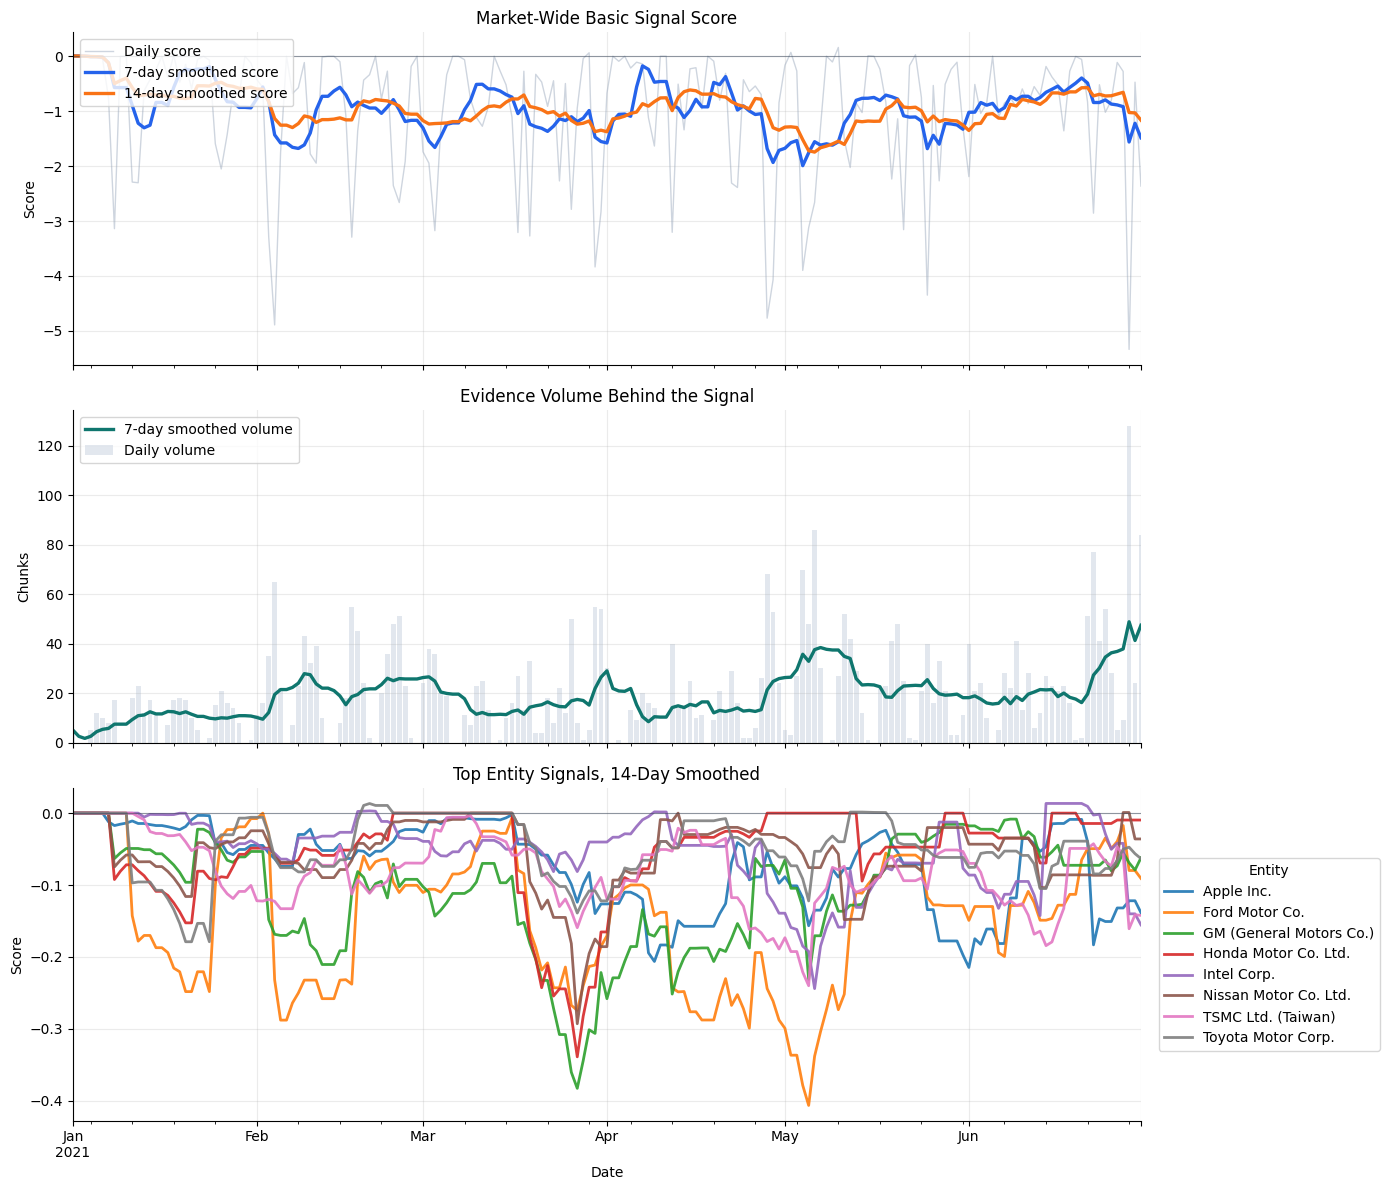

In [24]:
import matplotlib.pyplot as plt

# Basic signal statistics and smoothed time-series views
signal_plot_df = df_basic_signals.copy()
signal_plot_df["date"] = pd.to_datetime(signal_plot_df["date"])

if signal_plot_df.empty:
    print("No basic signal rows available to plot.")
else:
    display(signal_plot_df[["score", "volume"]].describe())

    daily_index = pd.date_range(
        signal_plot_df["date"].min(),
        signal_plot_df["date"].max(),
        freq="D",
    )
    market_daily = (
        signal_plot_df.groupby("date", as_index=True)
        .agg(score=("score", "sum"), volume=("volume", "sum"))
        .reindex(daily_index, fill_value=0)
        .rename_axis("date")
        .reset_index()
    )
    market_daily["score_7d"] = market_daily["score"].rolling(7, min_periods=1).mean()
    market_daily["score_14d"] = market_daily["score"].rolling(14, min_periods=1).mean()
    market_daily["volume_7d"] = market_daily["volume"].rolling(7, min_periods=1).mean()

    top_entities = (
        signal_plot_df.groupby("entity_name", dropna=False)["score"]
        .apply(lambda scores: scores.abs().sum())
        .sort_values(ascending=False)
        .head(8)
        .index
    )
    top_entity_daily = (
        signal_plot_df[signal_plot_df["entity_name"].isin(top_entities)]
        .pivot_table(index="date", columns="entity_name", values="score", aggfunc="sum")
        .reindex(daily_index, fill_value=0)
        .rolling(14, min_periods=1)
        .mean()
    )

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    axes[0].plot(
        market_daily["date"],
        market_daily["score"],
        color="#94a3b8",
        linewidth=1,
        alpha=0.45,
        label="Daily score",
    )
    axes[0].plot(
        market_daily["date"],
        market_daily["score_7d"],
        color="#2563eb",
        linewidth=2.4,
        label="7-day smoothed score",
    )
    axes[0].plot(
        market_daily["date"],
        market_daily["score_14d"],
        color="#f97316",
        linewidth=2.4,
        label="14-day smoothed score",
    )
    axes[0].axhline(0, color="#334155", linewidth=0.8, alpha=0.5)
    axes[0].set_title("Market-Wide Basic Signal Score")
    axes[0].set_ylabel("Score")
    axes[0].legend(loc="upper left")

    axes[1].bar(
        market_daily["date"],
        market_daily["volume"],
        color="#cbd5e1",
        alpha=0.55,
        label="Daily volume",
    )
    axes[1].plot(
        market_daily["date"],
        market_daily["volume_7d"],
        color="#0f766e",
        linewidth=2.4,
        label="7-day smoothed volume",
    )
    axes[1].set_title("Evidence Volume Behind the Signal")
    axes[1].set_ylabel("Chunks")
    axes[1].legend(loc="upper left")

    top_entity_daily.plot(ax=axes[2], linewidth=2, alpha=0.9)
    axes[2].axhline(0, color="#334155", linewidth=0.8, alpha=0.5)
    axes[2].set_title("Top Entity Signals, 14-Day Smoothed")
    axes[2].set_ylabel("Score")
    axes[2].set_xlabel("Date")
    axes[2].legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="Entity")

    for axis in axes:
        axis.grid(True, alpha=0.25)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()

## Summary

1. **Basic (relevance × sentiment):**
   - faster, broader, higher recall.

For robust research practice:
- test signal behavior across themes and market regimes,
- treat in-sample performance as a **sanity check**, not proof of persistent alpha.

Recommended next steps:
- compare basic signal information ratio and turnover,
- run robustness tests across alternate themes and windows,
- evaluate implementation frictions before any live deployment.

